<a href="https://colab.research.google.com/github/Divyan7/mini-project-on-pandas/blob/main/lab3_AP23110010152.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', 100)

In [ ]:
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(URL)
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("\nInfo:")
df.info()
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))
print("\nNumeric describe:")
df.describe().T


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values per column:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [ ]:
df.isna().sum().sort_values(ascending=False).head(10)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [ ]:
df_drop_rows = df.dropna(subset=['Age', 'Embarked'])  # drop rows where these are null
print("Original:", df.shape, "After drop:", df_drop_rows.shape)

Original: (891, 12) After drop: (712, 12)


In [ ]:
df_imp = df.copy()
# Numeric (Age): median
df_imp['Age'] = df_imp['Age'].fillna(df_imp['Age'].median())
# Categorical (Embarked): most frequent
df_imp['Embarked'] = df_imp['Embarked'].fillna(df_imp['Embarked'].mode()[0])

# 'Cabin' is very sparse; we can fill with "Unknown"
df_imp['Cabin'] = df_imp['Cabin'].fillna('Unknown')

df_imp.isna().sum().head(10)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
knn_df = df[num_cols].copy()
imputer = KNNImputer(n_neighbors=3)
knn_imputed = imputer.fit_transform(knn_df)
knn_imputed_df = pd.DataFrame(knn_imputed, columns=num_cols)
knn_imputed_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500


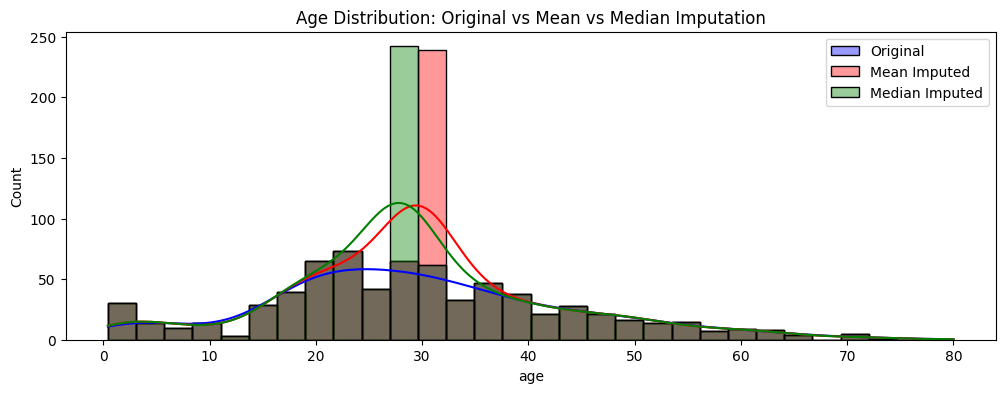


Original Embarked value_counts():
embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Embarked after Mode Imputation:
embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Embarked after 'Unknown' Imputation:
embarked
S          644
C          168
Q           77
Unknown      2
Name: count, dtype: int64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset from seaborn
titanic = sns.load_dataset("titanic")

# 1) Mean vs Median Imputation for Age

# Original distribution
plt.figure(figsize=(12,4))
sns.histplot(titanic["age"], kde=True, bins=30, color="blue", label="Original", alpha=0.4)

# Mean imputation
age_mean = titanic["age"].mean()
titanic_mean = titanic["age"].fillna(age_mean)
sns.histplot(titanic_mean, kde=True, bins=30, color="red", label="Mean Imputed", alpha=0.4)

# Median imputation
age_median = titanic["age"].median()
titanic_median = titanic["age"].fillna(age_median)
sns.histplot(titanic_median, kde=True, bins=30, color="green", label="Median Imputed", alpha=0.4)

plt.title("Age Distribution: Original vs Mean vs Median Imputation")
plt.legend()
plt.show()

# 2) Embarked: New Category vs Mode

print("\nOriginal Embarked value_counts():")
print(titanic["embarked"].value_counts(dropna=False))

# Fill with Mode
embarked_mode = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
print("\nEmbarked after Mode Imputation:")
print(embarked_mode.value_counts())

# Fill with 'Unknown'
embarked_unknown = titanic["embarked"].fillna("Unknown")
print("\nEmbarked after 'Unknown' Imputation:")
print(embarked_unknown.value_counts())


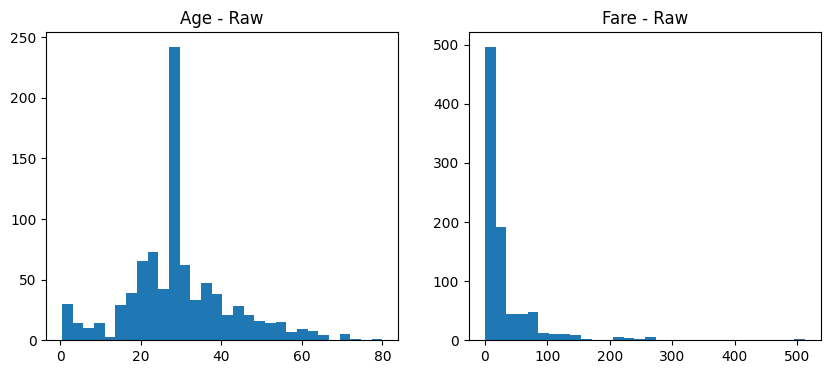

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(df_imp['Age'].dropna(), bins=30)
axes[0].set_title('Age - Raw')
axes[1].hist(df_imp['Fare'].dropna(), bins=30)
axes[1].set_title('Fare - Raw')
plt.show()

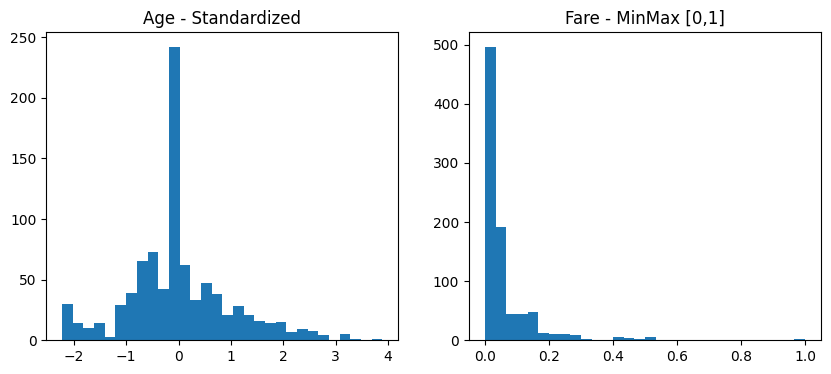

In [ ]:
sc_std = StandardScaler()
sc_mm  = MinMaxScaler()

age_std = sc_std.fit_transform(df_imp[['Age']])
fare_mm = sc_mm.fit_transform(df_imp[['Fare']])

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(age_std.flatten(), bins=30)
axes[0].set_title('Age - Standardized')
axes[1].hist(fare_mm.flatten(), bins=30)
axes[1].set_title('Fare - MinMax [0,1]')
plt.show()


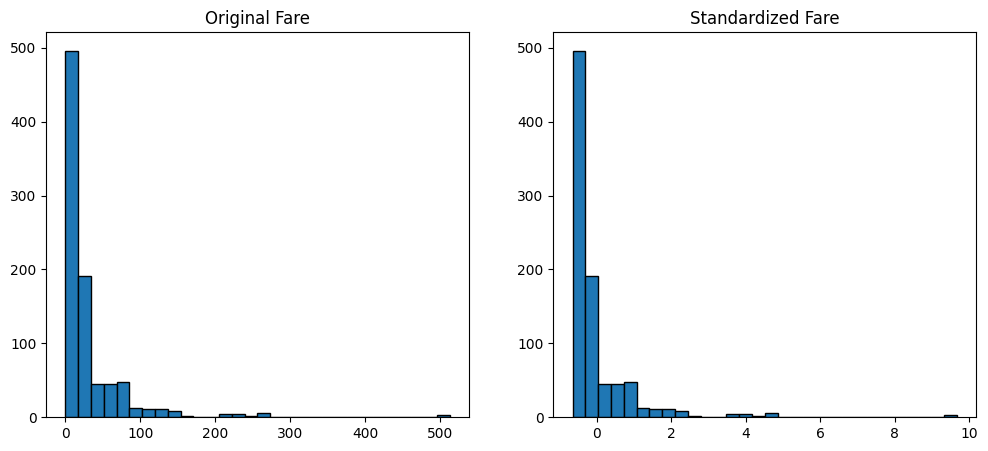

   Age_norm  Fare_norm
0  0.949757   0.312988
1  0.470417   0.882444
2  0.956551   0.291564
3  0.550338   0.834942
4  0.974555   0.224148


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, Normalizer

# Load dataset (assuming df is Titanic dataset)
# df = pd.read_csv("titanic.csv")

# Standardize Fare
scaler = StandardScaler()
df['Fare_scaled'] = scaler.fit_transform(df[['Fare']])

# Plot histogram
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['Fare'], bins=30, edgecolor="black")
plt.title("Original Fare")

plt.subplot(1,2,2)
plt.hist(df['Fare_scaled'], bins=30, edgecolor="black")
plt.title("Standardized Fare")
plt.show()

# Normalize Age and Fare row-wise
normalizer = Normalizer()
normalized = normalizer.fit_transform(df[['Age', 'Fare']].fillna(0))

norm_df = pd.DataFrame(normalized, columns=['Age_norm', 'Fare_norm'])
print(norm_df.head())


In [ ]:
enc = OrdinalEncoder()
ord_demo = df_imp[['Sex','Embarked']].copy()
ord_vals = enc.fit_transform(ord_demo)
pd.DataFrame(ord_vals, columns=['Sex_ord','Embarked_ord']).head()

,Sex_ord,Embarked_ord
0,1.0,2.0
1,0.0,0.0
2,0.0,2.0
3,0.0,2.0
4,1.0,2.0


In [ ]:
ohe_embarked = pd.get_dummies(df_imp['Embarked'], prefix='Embarked')
ohe_sex = pd.get_dummies(df_imp['Sex'], prefix='Sex')
encoded_df = pd.concat([df_imp[['Survived','Age','Fare']], ohe_sex, ohe_embarked], axis=1)
encoded_df.head()

,Survived,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,22.0,7.2500,False,True,False,False,True
1,1,38.0,71.2833,True,False,True,False,False
2,1,26.0,7.9250,True,False,False,False,True
3,1,35.0,53.1000,True,False,False,False,True
4,0,35.0,8.0500,False,True,False,False,True


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Use Embarked with missing filled (mode)
embarked = titanic[["embarked"]].fillna(titanic["embarked"].mode()[0])

# ----- Ordinal Encoding -----
ord_enc = OrdinalEncoder()
embarked_ord = ord_enc.fit_transform(embarked)
print("Ordinal Encoding shape:", embarked_ord.shape)
print("Categories:", ord_enc.categories_)

# ----- One-Hot Encoding -----
onehot_enc = OneHotEncoder(drop=None)
embarked_ohe = onehot_enc.fit_transform(embarked)
print("\nOne-Hot Encoding shape:", embarked_ohe.shape)
print("Categories:", onehot_enc.categories_)

Ordinal Encoding shape: (891, 1)
Categories: [array(['C', 'Q', 'S'], dtype=object)]

One-Hot Encoding shape: (891, 3)
Categories: [array(['C', 'Q', 'S'], dtype=object)]


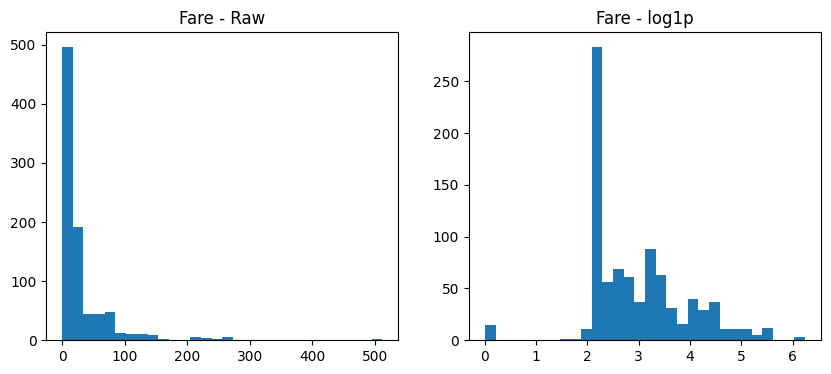

In [ ]:
fare_raw = df_imp['Fare'].dropna().values.reshape(-1,1)
fare_log = np.log1p(fare_raw)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(fare_raw.flatten(), bins=30)
axes[0].set_title('Fare - Raw')
axes[1].hist(fare_log.flatten(), bins=30)
axes[1].set_title('Fare - log1p')
plt.show()

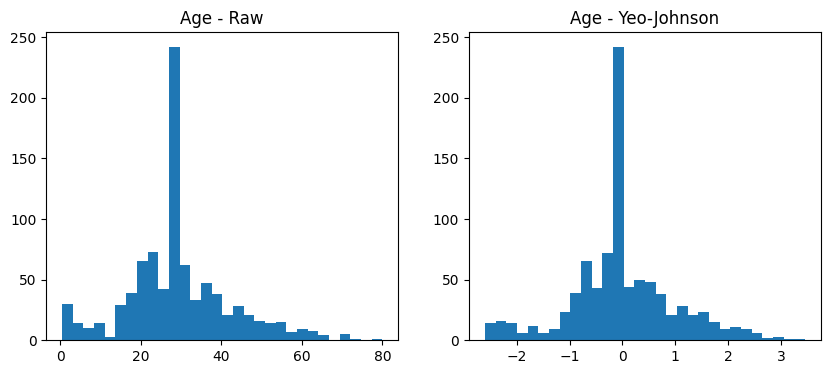

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
af = df_imp[['Age','Fare']].dropna()
af_pt = pt.fit_transform(af)

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(af['Age'].values, bins=30)
axes[0].set_title('Age - Raw')
axes[1].hist(af_pt[:,0], bins=30)
axes[1].set_title('Age - Yeo-Johnson')
plt.show()


In [ ]:
poly = PolynomialFeatures(degree=2, include_bias=False)
af_poly = poly.fit_transform(af[['Age','Fare']])
print("Original shape:", af[['Age','Fare']].shape, " -> With poly:", af_poly.shape)
poly.get_feature_names_out(['Age','Fare'])[:6]

Original shape: (891, 2)  -> With poly: (891, 5)


array(['Age', 'Fare', 'Age^2', 'Age Fare', 'Fare^2'], dtype=object)

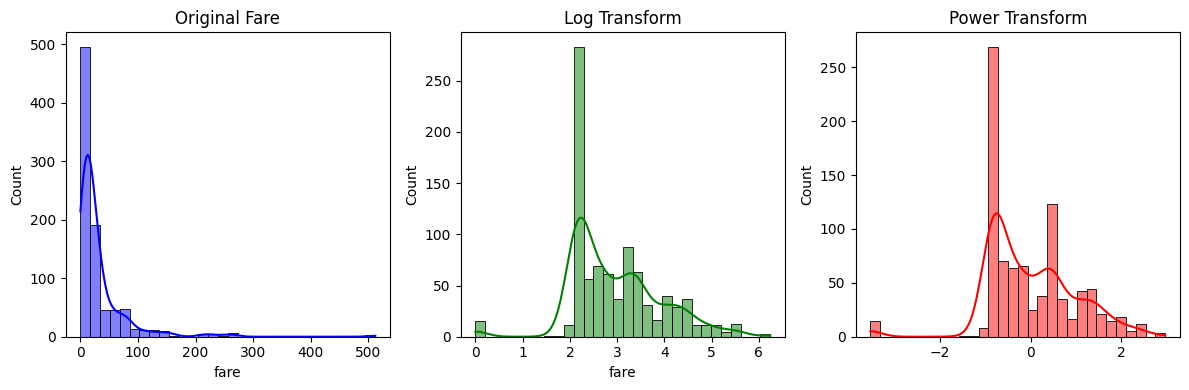

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Load dataset
titanic = sns.load_dataset("titanic")

# Choose a skewed numeric column: Fare (right-skewed)
fare = titanic["fare"].dropna()

# Plot original distribution
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(fare, bins=30, kde=True, color="blue")
plt.title("Original Fare")

# Log transform (add 1 to avoid log(0))
fare_log = np.log1p(fare)
plt.subplot(1,3,2)
sns.histplot(fare_log, bins=30, kde=True, color="green")
plt.title("Log Transform")

# Power transform (Yeo-Johnson handles 0+)
pt = PowerTransformer(method='yeo-johnson')
fare_power = pt.fit_transform(fare.values.reshape(-1,1))
plt.subplot(1,3,3)
sns.histplot(fare_power[:,0], bins=30, kde=True, color="red")
plt.title("Power Transform")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Take Age and Fare columns
X = titanic[["age","fare"]].dropna()

# Generate polynomial features of degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Show feature names
print("Polynomial feature names:")
print(poly.get_feature_names_out(["age","fare"]))


Polynomial feature names:
['age' 'fare' 'age^2' 'age fare' 'fare^2']


Explained variance ratios: [0.96165195 0.03587775]


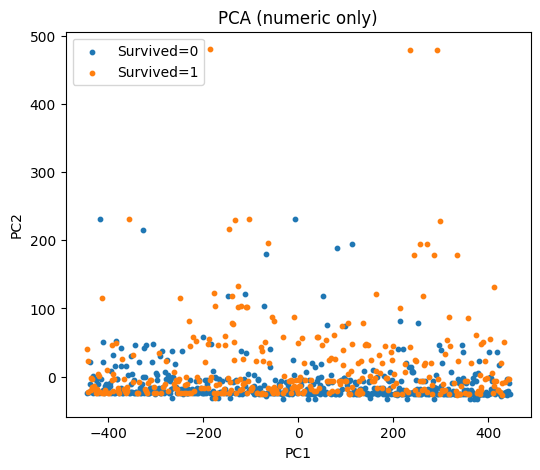

In [ ]:
num_only = df_imp.select_dtypes(include=['number']).dropna()
y = df_imp.loc[num_only.index, 'Survived'] if 'Survived' in df_imp.columns else None

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(num_only.values)

print("Explained variance ratios:", pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(6,5))
if y is not None:
    # Color by Survived (0/1). Using a simple split to avoid specifying colors.
    idx0 = (y.values == 0)
    idx1 = (y.values == 1)
    plt.scatter(Z[idx0,0], Z[idx0,1], s=10, label='Survived=0')
    plt.scatter(Z[idx1,0], Z[idx1,1], s=10, label='Survived=1')
    plt.legend()
else:
    plt.scatter(Z[:,0], Z[:,1], s=10)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (numeric only)')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
titanic = sns.load_dataset("titanic")

# Select only numeric columns
num_df = titanic.select_dtypes(include=["number"]).dropna()

# Variance of each numeric column
variances = num_df.var().sort_values(ascending=False)
print("Variance of numeric columns:\n", variances)

# Top 2 contributors
print("\nTop 2 columns contributing most variance:")
print(variances.head(2))


Variance of numeric columns:
 fare        2800.413100
age          211.019125
sibsp          0.864497
parch          0.728103
pclass         0.702663
survived       0.241533
dtype: float64

Top 2 columns contributing most variance:
fare    2800.413100
age      211.019125
dtype: float64


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Standardize before PCA
X_scaled = StandardScaler().fit_transform(num_df)

# PCA with 3 components
pca = PCA(n_components=3)
pca.fit(X_scaled)

# Explained variance ratio
print("\nExplained variance ratio per component:")
print(pca.explained_variance_ratio_)

# Cumulative explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative explained variance (3 comps):", cum_var[-1])



Explained variance ratio per component:
[0.31491585 0.27779838 0.15423038]

Cumulative explained variance (3 comps): 0.7469446138230644


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


data = df_imp.copy()

data["Age_scaled"] = StandardScaler().fit_transform(data[["Age"]])
data["Fare_scaled"] = MinMaxScaler().fit_transform(data[["Fare"]].fillna(0))

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(data[["Sex","Embarked"]])
encoded_cols = ohe.get_feature_names_out(["Sex","Embarked"])
encoded_df = pd.DataFrame(encoded, columns=encoded_cols)
data = pd.concat([data.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

data["Fare_log"] = np.log1p(data["Fare"])

X = data[["Age_scaled","Fare_scaled","Fare_log"] + list(encoded_df.columns)]
y = data["Survived"].dropna()
X = X.loc[y.index]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.7757847533632287
